In [1]:
import numpy as np
a= np.array([1,2,3])
a

array([1, 2, 3])

概率

In [2]:
import torch
from torch.distributions import multinomial
#多项分布（multinomial distribution），抽样（sampling）
fair_probs = torch.ones([6]) / 6
#单次抽样
multinomial.Multinomial(1, fair_probs).sample()

tensor([0., 0., 0., 0., 1., 0.])

multinomial.Multinomial(1, fair_probs).sample() 创建了一个多项分布对象，其中第一个参数1表示总试验次数（这里是单次投掷），第二个参数fair_probs是每个结果的概率向量。然后调用.sample()方法进行一次抽样，返回一个张量，表示这次抽样中每个结果出现的次数。由于总次数为1，结果将是一个one-hot编码的向量，例如[0, 0, 1, 0, 0, 0]，表示第三个面出现了1次，其他为0。这模拟了投掷骰子一次的结果

In [3]:
#尝试进行多次抽样
multinomial.Multinomial(10, fair_probs).sample()

tensor([3., 0., 1., 2., 2., 2.])

In [4]:
# 将结果存储为32位浮点数以进行除法
counts = multinomial.Multinomial(1000, fair_probs).sample()
counts / 1000 # 相对频率作为估计值

tensor([0.1810, 0.1490, 0.1380, 0.1840, 0.1730, 0.1750])

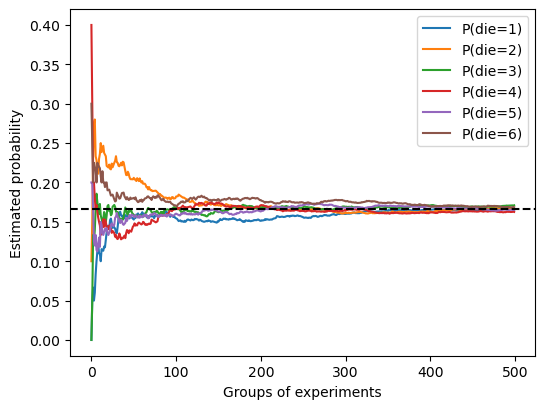

In [14]:
import matplotlib.pyplot as plt

counts = multinomial.Multinomial(10, fair_probs).sample((500,))
cum_counts = counts.cumsum(dim=0)
estimates = cum_counts / cum_counts.sum(dim=1, keepdims=True)

plt.figure(figsize=(6, 4.5))
for i in range(6):
	plt.plot(estimates[:, i].numpy(), label=f"P(die={i+1})")
plt.axhline(y=1/6, color='black', linestyle='dashed')
plt.gca().set_xlabel('Groups of experiments')
plt.gca().set_ylabel('Estimated probability')
plt.legend();